# Full ML Pipeline : EDA | Preprocessing | Modelling | Evaluation | Deployment
##  Before doing anything, answer these questions:
- what is the exact question I am trying to answer?
- Is this a classification or regression problem(supervised)
- what is the target variable(y) (or column you are trying to predict)
- what are the features the model is going to use(X), (columns in x).
- what metrics are you going to use to measure sucess (metrics to use eg accuracy, precision of recall )
 
# Explanatory Data Analysis
1. Understand the structure and the quality of your dataset.
2. identify the missing values, outliers and class inbalance(this is where when you look at your y one class has so many values compared to the other ie 80/20).
3. Visualize distributions and relationships between features. heat maps, bar charts.
 
## EDA checklist
1. Load and inspect.
python
    df.head()
    df.shape
    df.dtypes
    df.info()

no. of rows/columns, data types, and obvious issues eg missing
 
2. Summary Statistics
python
    df.describe() gives the range, the means the extremes, max, min,

3. Missing Values
python
    df.isnull().sum()

which column is missing, how much, pattern or random.
4. Check the Target Distribution
python
    df[target].value_counts()

show class imbalance, whether one has skewed dist etc
5. Feature Distribution
df.hist() or sns.boxplot() , normal, skewed or has outliers.
 
6. Correlations
df.corr() + heatmap
Highly correlated features,
 
7. Feature vs target
Scatter plots, boxplots per class




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Titanic-Dataset (1).csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Basic Inspection
print("Basic inspection results:")
print(f"shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
 
print("First 5 rows: ")
print(df.head())
 
print("Data types")
print(df.dtypes)

Basic inspection results:
shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
First 5 rows: 
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71

In [6]:
print("Data types: ")
print(df.dtypes)

Data types: 
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [7]:
# 2. Summary statistics.
print("Summary statistics")
print(df.describe().round(2))

Summary statistics
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


In [8]:
#3. Missing values.
print("Missing values: ")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count': missing, 
    'percentage': missing_pct
})

print(missing_df[missing_df['count'] > 0 ].sort_values('percentage', ascending=False))

Missing values: 
          count  percentage
Cabin       687   77.104377
Age         177   19.865320
Embarked      2    0.224467


In [9]:
# 4. Target distribution.
TARGET = 'Survived'
print("Target distribution")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(3)) # to see class Imbalance

# Imbalance > 80/20 needs some handling.

Target distribution
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


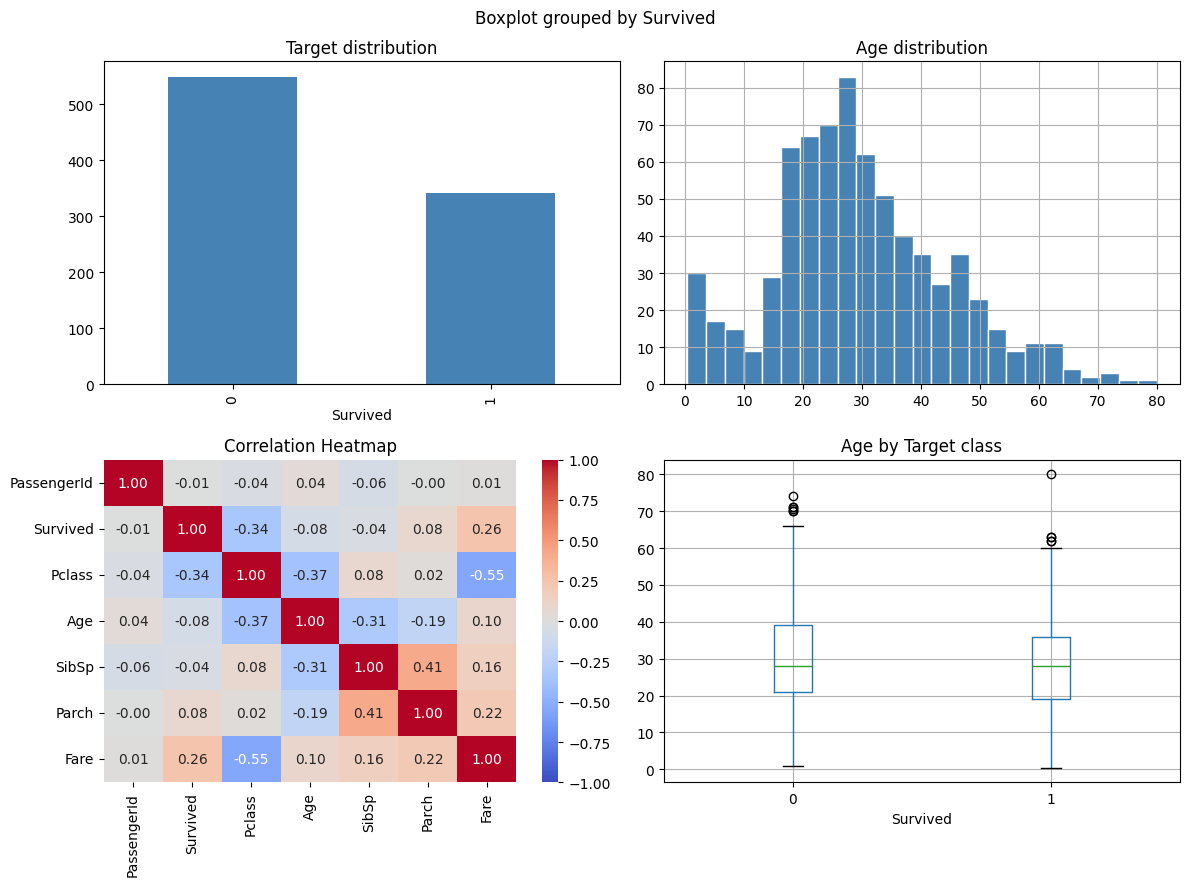

EDA complete


In [10]:
# 5. Visualizations.
fig, axes = plt.subplots(2, 2, figsize= (12, 9))

# Target distribution
df[TARGET].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Target distribution')

# feature distribution (age)
df['Age'].dropna().hist(ax=axes[0,1], bins=25, color='steelblue', edgecolor='white')
axes[0,1].set_title('Age distribution')

# correlation heatmap (numerical columns only)
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,0], vmin=-1,
             vmax=1)
axes[1,0].set_title('Correlation Heatmap')

# Feature vs target (age vs survived)
df.boxplot(column='Age', by=TARGET, ax=axes[1,1])
axes[1,1].set_title('Age by Target class')

plt.tight_layout()
plt.show()
print("EDA complete") # Make sure you note your findings before proceeding.


## EDA Findings template
1. How many rows and columns.
2. Which columns have missing data and how much?
3. Is the target class balanced or imbalanced.
4. which features appear most correlated with the target.
5. Are there any obvious outliers to address
6. Which columns are you going to drop and why?


# Preprocessing pipeline
-Handle all missing values with appropriate strategies.
- Encode categorical columns correctly.
- Build a full ColumnTransformer + Pipeline.
 
## Preprocessing decision checklist
1. Columns to drop. Options: id, free text, >70% missing, zero variance.
2. Numeric imputation. Options: median(default), mean, constant(-1).
3. Categorical imputation Options: most-frequent, constant("Unknown).
4. Categorical encoding, Options: One_hot(<15 cats>), Labels (ordinal), Target(high cardinality).
5. Numeric Scaling. Options: StandardScaler(default), MinMaxScaler, RobustScaler(many outliers).
6. Class imbalance. Options: None, SMOTE, class_weight='balanced'

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [12]:
#1. select and clean columns
df_clean = df.copy() # making a copy of the original dataset as a backup

In [13]:
#2. Drop columns that we are not going to use.
cols_to_drop = ['PassengerId', "Name", "Cabin", "Ticket", "doesntExist"]
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean]) #the 'in' helps in error handling.

In [14]:
#Separating features from target
TARGET = 'Survived'
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

In [15]:
#Exploring Features
print(f"Features remaining: {list[X.columns]}")
print(f"Shape of features: {X.shape}")
print(f"The target: {TARGET}")

Features remaining: list[Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')]
Shape of features: (891, 7)
The target: Survived


In [16]:
#splitting then preprocessing,
#stratify- ensures that your training and
#testing sets maintain the same class proportions as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=y)
print(f"Train: {X_train.shape} Test: {X_test.shape}")

Train: (712, 7) Test: (179, 7)


In [17]:
#The processings begins now
#Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['str']).columns.tolist()
 
print(f'Numerical: {num_cols}')
print(f"Categorical: {cat_cols}")

Numerical: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Sex', 'Embarked']


In [18]:
#Building the pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
 
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])
 
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
 
X_tr_transformed = preprocessor.fit_transform(X_train)
print(f'After preprocessing X trained: {X_tr_transformed.shape}')
print("Ready to add model if no errors")



After preprocessing X trained: (712, 8)
Ready to add model if no errors


In [19]:
X['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [20]:
X['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

## Modelling, evaluation and tuning
### Objectives
1. Train at least 2 different models using the preprocessing pipeline.
2. Compare the models using cross-validation and choose the best one.
3. Tune the best model with RandomizedSearchCV or Optuna.
4. Produce a final evaluation (eg accuracy, precision, r2 score)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [22]:
#saving the models in a dictionary
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier() 
}

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [24]:
results = {}

for name,model in models.items():

    full_pipe = Pipeline([
        ('preprocessor', preprocessor), 
        ('model', model),
    
    ])
    acc_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='accuracy')

    f1_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='f1')

    results[name]= {'acc_scores': acc_scores.mean(), 'f1': f1_scores.mean()}



In [25]:
results

{'Logistic Regression': {'acc_scores': np.float64(0.7949374569092879),
  'f1': np.float64(0.7246353792381143)},
 'Random Forest': {'acc_scores': np.float64(0.794937456909288),
  'f1': np.float64(0.7288683145600695)},
 'Gradient Boosting': {'acc_scores': np.float64(0.8258347286516299),
  'f1': np.float64(0.7587872046093072)},
 'KNN': {'acc_scores': np.float64(0.7977839062346105),
  'f1': np.float64(0.721238400224206)}}

In [26]:
best_name = max(results, key=lambda  k: results[k]['f1'])  # 'k' key of outer dictionary, f1 key of inner dictinary

best_name

'Gradient Boosting'

In [27]:
# Tuning Random forest

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint  # for generating random integers

params_dist = {
    'model__n_estimators': randint(50, 400),
    'model__max_depth': randint(2, 25),
    'model__min_samples_split': randint(2, 15),
    'model__min_samples_leaf': randint(1,8)

}

best_pipe = Pipeline ([
    ('preprocessor', preprocessor),
    ('model',RandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(best_pipe, params_dist, n_iter=50, cv=5, scoring='f1', n_jobs=-1, verbose=2)
search.fit(X_train, y_train)
print(f'best fold f1{search.best_score_:.4f}')
print(f'best_params{search.best_params_}')


Fitting 5 folds for each of 50 candidates, totalling 250 fits
best fold f10.7646
best_params{'model__max_depth': 16, 'model__min_samples_leaf': 1, 'model__min_samples_split': 9, 'model__n_estimators': 68}


In [28]:
#final evaluation
final_model = search.best_estimator_.fit(X_train, y_train)

final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [29]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = final_model.predict(X_test)

classification_report(y_test, y_pred)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



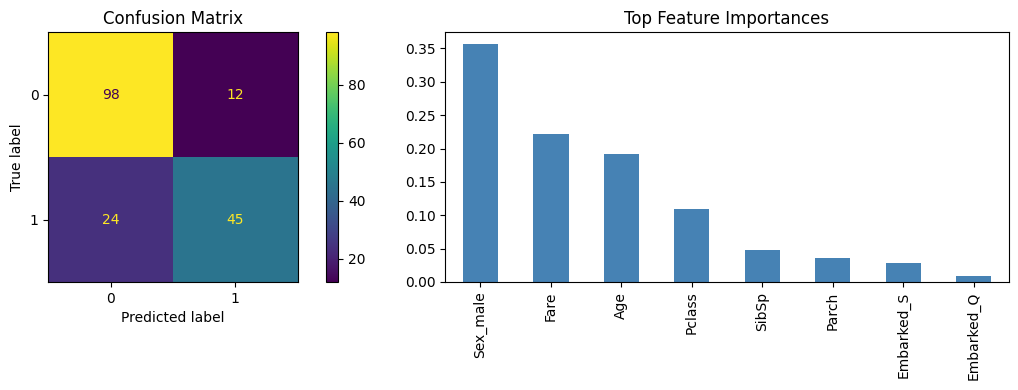

In [33]:
import matplotlib.pyplot as plt

fig,axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])

axes[0].set_title('Confusion Matrix')


# Right plot

if hasattr(final_model['model'], 'feature_importances_'):
    # Extract the feature names.
    num_names = num_cols
    cat_names = (final_model['preprocessor'].named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols).tolist())

    all_names = num_names + cat_names

    # Mapping important names
    importances= pd.Series(final_model['model'].feature_importances_, index=all_names).sort_values(ascending=False)

    # Plotting
    importances.plot(kind='bar', ax=axes[1], color='steelblue')

    axes[1].set_title('Top Feature Importances')

plt.tight_layout()
plt.show()